In [56]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import load_dataset
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchinfo import summary
from torchvision import transforms

In [57]:
class SimpleCNN(nn.Module):
    """Simple CNN for binary classification of cats vs dogs."""

    def __init__(self, num_classes=2):
        super(SimpleCNN, self).__init__()

        # Convolutional Block 1
        # Input: (batch_size, 3, H, W) - RGB images
        # Output: (batch_size, 32, H/2, W/2) - 32 feature maps, half the spatial size
        self.conv_block1 = nn.Sequential(
            # First conv: 3 input channels (RGB) → 32 output feature maps
            # kernel_size=3: uses 3x3 filters, padding=1: maintains spatial dimensions
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),  # Normalizes the 32 feature maps for stable training
            nn.ReLU(),  # Non-linear activation function
            # Second conv: 32 → 32 feature maps, learns more complex patterns
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            # Downsample by 2x: reduces spatial dimensions (e.g., 224x224 → 112x112)
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Convolutional Block 2
        # Input: (batch_size, 32, H/2, W/2)
        # Output: (batch_size, 64, H/4, W/4) - doubles feature maps, halves spatial size
        self.conv_block2 = nn.Sequential(
            # Increase depth: 32 → 64 feature maps for learning more complex features
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Second conv at this depth level
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            # Downsample again: (e.g., 112x112 → 56x56)
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # Convolutional Block 3
        # Input: (batch_size, 64, H/4, W/4)
        # Output: (batch_size, 128, 4, 4) - highest-level features, fixed 4x4 spatial size
        self.conv_block3 = nn.Sequential(
            # Increase depth: 64 → 128 feature maps for high-level feature learning
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Second conv at this depth level
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            # Final spatial downsampling (e.g., 56x56 → 28x28)
            nn.MaxPool2d(kernel_size=2, stride=2),
            # Adaptive pooling: converts any spatial size to fixed 4x4
            # This makes the network flexible to different input image sizes
            nn.AdaptiveAvgPool2d((4, 4)),
        )

        # Fully Connected Layers (Classifier)
        # Input: (batch_size, 128, 4, 4) = flattened to (batch_size, 2048)
        # Output: (batch_size, 2) - raw scores for cat and dog classes
        self.classifier = nn.Sequential(
            # Flatten 3D feature maps into 1D vector: 128×4×4 = 2048 features
            nn.Flatten(),
            # First dense layer: 2048 → 512 neurons
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),  # Randomly drop 50% of neurons during training to prevent overfitting
            # Second dense layer: 512 → 256 neurons
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),  # Another dropout layer for regularization
            # Output layer: 256 → 2 class scores (logits for cat and dog)
            nn.Linear(256, 2),
        )

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of shape (batch_size, 3, H, W)

        Returns:
            Output tensor of shape (batch_size, 2) containing class logits
        """
        # Pass through convolutional blocks to extract features
        x = self.conv_block1(x)  # Extract low-level features (edges, textures)
        x = self.conv_block2(x)  # Extract mid-level features (shapes, patterns)
        x = self.conv_block3(x)  # Extract high-level features (animal parts, structures)

        # Pass through classifier to get final predictions
        x = self.classifier(x)  # Convert features to class scores

        return x  # Returns raw logits (use with CrossEntropyLoss or apply softmax for probabilities)

In [58]:
class CatsDogsDataset(Dataset):
    """PyTorch Dataset for Cats vs Dogs."""

    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]

        # Convert numpy array to PIL Image if needed
        if isinstance(image, np.ndarray):
            image = Image.fromarray(image.astype("uint8"))

        if self.transform:
            image = self.transform(image)

        return image, label

In [59]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in dataloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [60]:
def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

In [61]:
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_preds), np.array(all_labels)

In [62]:
def plot_training_history(history):
    """Plot training and validation loss and accuracy."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot loss
    ax1.plot(history["train_loss"], label="Train Loss", marker="o", linewidth=2)
    ax1.plot(history["val_loss"], label="Validation Loss", marker="o", linewidth=2)
    ax1.set_xlabel("Epoch", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.set_title("Training and Validation Loss", fontsize=14, fontweight="bold")
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Plot accuracy
    ax2.plot(history["train_acc"], label="Train Accuracy", marker="o", linewidth=2)
    ax2.plot(history["val_acc"], label="Validation Accuracy", marker="o", linewidth=2)
    ax2.set_xlabel("Epoch", fontsize=12)
    ax2.set_ylabel("Accuracy (%)", fontsize=12)
    ax2.set_title("Training and Validation Accuracy", fontsize=14, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_history.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Training history plot saved as 'training_history.png'\n")

In [63]:
def plot_confusion_matrix(y_true, y_pred, classes=["Cat (0)", "Dog (1)"]):
    """Plot confusion matrix using matplotlib."""
    cm = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(8, 6))

    # Create heatmap using imshow
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Count", rotation=270, labelpad=20)

    # Set ticks and labels
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    # Rotate the tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add text annotations
    thresh = cm.max() / 2.0
    for i in range(len(classes)):
        for j in range(len(classes)):
            ax.text(
                j,
                i,
                format(cm[i, j], "d"),
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14,
            )

    ax.set_xlabel("Predicted Label", fontsize=12, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=12, fontweight="bold")
    ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Confusion matrix saved as 'confusion_matrix.png'\n")

In [64]:
def print_classification_report(y_true, y_pred, classes=["Cat (0)", "Dog (1)"]):
    """Print and save classification report."""
    print("=" * 80)
    print("CLASSIFICATION REPORT ON TEST DATASET")
    print("=" * 80)

    report = classification_report(y_true, y_pred, target_names=classes, digits=4)
    print(report)

    # Save to file
    with open("classification_report.txt", "w") as f:
        f.write("CLASSIFICATION REPORT ON TEST DATASET\n")
        f.write("=" * 80 + "\n")
        f.write(report)

    print("=" * 80)
    print("Classification report saved as 'classification_report.txt'\n")

Using device: cuda

DATA LOADING
Loading dataset
Preparing images...
Total images: 4000
Label distribution: (array([0, 1]), array([2000, 2000]))


Train set: 2800 images
Validation set: 600 images
Test set: 600 images

Creating datasets...
✓ Datasets ready!

SimpleCNN(
  (conv_block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), s

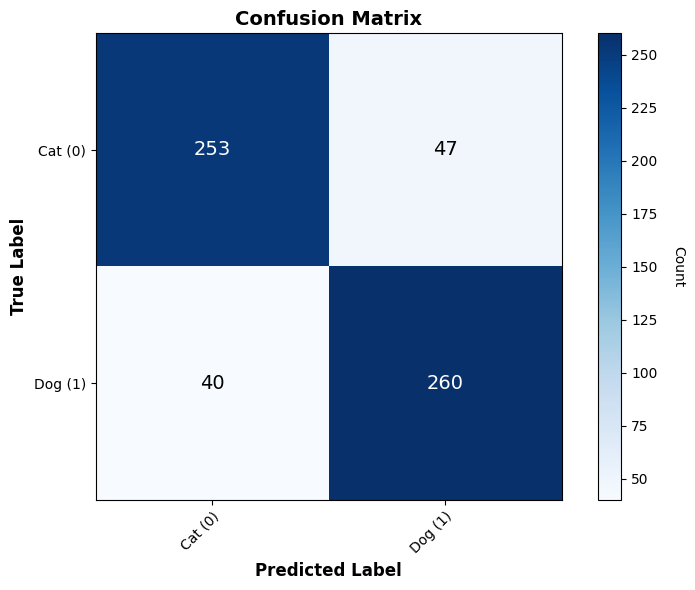

Confusion matrix saved as 'confusion_matrix.png'

CLASSIFICATION REPORT ON TEST DATASET
              precision    recall  f1-score   support

     Cat (0)     0.8635    0.8433    0.8533       300
     Dog (1)     0.8469    0.8667    0.8567       300

    accuracy                         0.8550       600
   macro avg     0.8552    0.8550    0.8550       600
weighted avg     0.8552    0.8550    0.8550       600

Classification report saved as 'classification_report.txt'


Final Test Accuracy: 85.50%


In [ ]:
# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001
NUM_CLASSES = 2

# Control flags
FORCE_RETRAIN = False  # Set to True to retrain even if model exists
MODEL_PATH = "best_model.pth"

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\n")

# ============================================================================
# HELPER: Check if we should skip training
# ============================================================================
def should_skip_training():
    """Check if model exists and we shouldn't force retrain."""
    if FORCE_RETRAIN:
        print("⚠️ FORCE_RETRAIN is True - will retrain model")
        return False

    if os.path.exists(MODEL_PATH):
        print(f"Found existing model at '{MODEL_PATH}'")
        print("  Set FORCE_RETRAIN=True to retrain")
        return True

    print("✗ No existing model found - will train")
    return False

# ============================================================================
# 1. LOAD AND PREPARE DATA
# ============================================================================
print("=" * 80)
print("DATA LOADING")
print("=" * 80)
print("Loading dataset")
data = load_dataset("pantelism/cats-vs-dogs")

print("Preparing images...")
train_images = [img for img in data["train"]["image"]]
train_labels = np.array(data["train"]["label"])

print(f"Total images: {len(train_images)}")
print(f"Label distribution: {np.unique(train_labels, return_counts=True)}\n")

# Split into train, validation, and test
train_imgs, temp_imgs, train_lbls, temp_lbls = train_test_split(
    train_images, train_labels, test_size=0.3, random_state=42, stratify=train_labels
)

val_imgs, test_imgs, val_lbls, test_lbls = train_test_split(
    temp_imgs, temp_lbls, test_size=0.5, random_state=42, stratify=temp_lbls
)

print(f"\nTrain set: {len(train_imgs)} images")
print(f"Validation set: {len(val_imgs)} images")
print(f"Test set: {len(test_imgs)} images\n")

# ============================================================================
# 2. CREATE DATASETS AND DATALOADERS
# ============================================================================
print("Creating datasets...")

# Data transforms
train_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_transform = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

# Create datasets and dataloaders
train_dataset = CatsDogsDataset(train_imgs, train_lbls, transform=train_transform)
val_dataset = CatsDogsDataset(val_imgs, val_lbls, transform=val_transform)
test_dataset = CatsDogsDataset(test_imgs, test_lbls, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("✓ Datasets ready!\n")

# ============================================================================
# 3. CREATE MODEL
# ============================================================================
model = SimpleCNN(num_classes=NUM_CLASSES)
model = model.to(device)

# Print model summary, must print summary or else it does not show on notebooks
print(model)
print("\n" + "=" * 80)
print("MODEL SUMMARY")
print("=" * 80)
print(
    summary(
        model,
        input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE),
        col_names=["input_size", "output_size", "num_params"],
        depth=3,
    )
)
print("=" * 80 + "\n")

# ============================================================================
# 4. TRAIN THE MODEL (OR SKIP IF MODEL EXISTS)
# ============================================================================
if should_skip_training():
    print("\nSKIPPING TRAINING - Loading existing model\n")
    model.load_state_dict(torch.load(MODEL_PATH))
    print(f"Model loaded from '{MODEL_PATH}'\n")

else:
    print("\n" + "=" * 80)
    print("TRAINING MODEL")
    print("=" * 80)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    print("Starting training...\n")
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    best_val_acc = 0.0

    for epoch in range(EPOCHS):
        print(f"Epoch {epoch + 1}/{EPOCHS}")
        print("-" * 40)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

        # Validate
        val_loss, val_acc = validate(model, val_loader, criterion, device)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

        # Learning rate scheduling
        scheduler.step(val_loss)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), MODEL_PATH)
            print("Model saved!")
        print()

    print(f"Training complete! Best validation accuracy: {best_val_acc:.2f}%\n")

    # Plot training history
    plot_training_history(history)

    # Load best model
    model.load_state_dict(torch.load(MODEL_PATH))

# ============================================================================
# 5. EVALUATE ON TEST SET
# ============================================================================
print("\n" + "=" * 80)
print("TEST SET EVALUATION")
print("=" * 80)

criterion = nn.CrossEntropyLoss()

print("Evaluating on test set...")
test_loss, test_acc = validate(model, test_loader, criterion, device)
print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%\n")

# Confusion Matrix
print("Generating predictions...")
y_pred, y_true = get_predictions(model, test_loader, device)
plot_confusion_matrix(y_true, y_pred, classes=["Cat (0)", "Dog (1)"])

# Classification Report
print_classification_report(y_true, y_pred, classes=["Cat (0)", "Dog (1)"])

# ========================================================================
# SUMMARY
# ========================================================================

print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
print("=" * 80)